In [ ]:
from qiskit.visualization import plot_histogram
from qiskit.quantum_info import Statevector, Operator, partial_trace, SparsePauliOp
from qiskit import qpy, QuantumCircuit
import numpy as np
from qiskit.synthesis import TwoQubitWeylDecomposition
from qiskit_aer import AerSimulator
from QuditsOnQubits import create_ame_circuit, generate_b_ame, draw_graph
from sympy.functions.combinatorial.numbers import legendre_symbol
from IPython.display import display, Math
from itertools import product
from qiskit_aer.primitives import EstimatorV2 as AerEstimator
from qiskit_aer.primitives import SamplerV2 as AerSampler
from qiskit.circuit import QuantumCircuit
from qiskit.circuit.library import StatePreparation
from igraph import Graph, plot
import matplotlib.pyplot as plt
import matplotlib.ticker as tck
from qiskit_ibm_runtime import Session, Batch, EstimatorV2 as Estimator
from qiskit_ibm_runtime import SamplerV2 as Sampler
from qiskit_ibm_runtime import QiskitRuntimeService
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager

with open('Xgate3.qpy', 'rb') as fd:
    Xgate3 = qpy.load(fd)[0]

with open('Zgate3.qpy', 'rb') as fd:
    Zgate3 = qpy.load(fd)[0]

with open('Xgate4.qpy', 'rb') as fd:
    Xgate4 = qpy.load(fd)[0]

with open('Zgate4.qpy', 'rb') as fd:
    Zgate4 = qpy.load(fd)[0]

with open('Xgate3dag.qpy', 'rb') as fd:
    Xgate3dag = qpy.load(fd)[0]

with open('Zgate3dag.qpy', 'rb') as fd:
    Zgate3dag = qpy.load(fd)[0]

with open('Xgate4dag.qpy', 'rb') as fd:
    Xgate4dag = qpy.load(fd)[0]

with open('Zgate4dag.qpy', 'rb') as fd:
    Zgate4dag = qpy.load(fd)[0]

with open('FDAGgate3.qpy', 'rb') as fd:
    FDAGgate3 = qpy.load(fd)[0]

with open('FDAGgate4.qpy', 'rb') as fd:
    FDAGgate4 = qpy.load(fd)[0]

In [2]:
qc2, g2 = create_ame_circuit(2, 3)
qc2.append(FDAGgate3, [2, 3])

In [5]:
qc3, g3 = create_ame_circuit(3, 3)

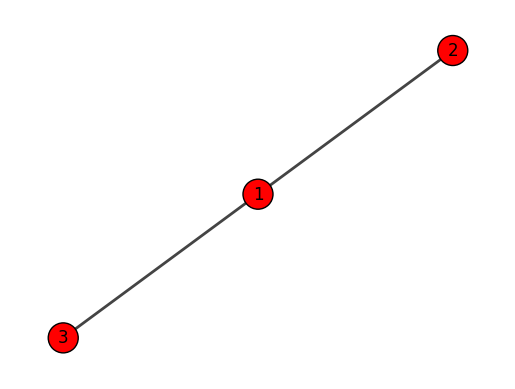

In [7]:
draw_graph(g3)

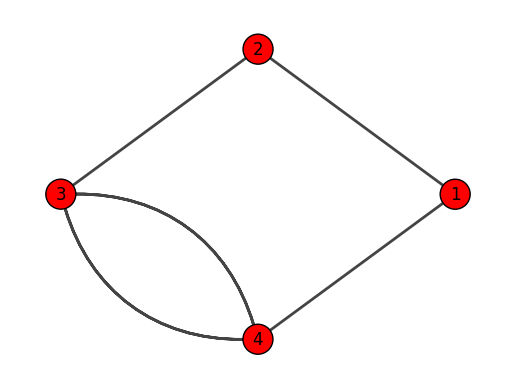

In [8]:
game43 = Graph(n=4, edges=[[0, 1], [1, 2], [2, 3], [2, 3], [3, 0]])
game43.vs["name"] = [i+1 for i in range(game43.vcount())]
fig, ax = plt.subplots()
plot(game43, target=ax, vertex_label=game43.vs["name"])

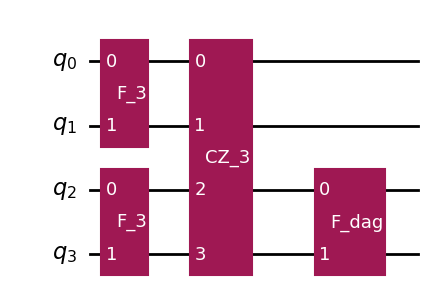

In [6]:
qc2.draw("mpl")

In [7]:
Statevector(qc2).draw('latex')

<IPython.core.display.Latex object>

In [9]:
def x01():
    mtx = np.array([
        [0, 1, 0, 0],
        [1, 0, 0, 0],
        [0, 0, 0, 0],
        [0, 0, 0, 0]
    ])

    return Operator(mtx)

def x02():
    mtx = np.array([
        [0, 0, 1, 0],
        [0, 0, 0, 0],
        [1, 0, 0, 0],
        [0, 0, 0, 0]
    ])

    return Operator(mtx)

def x12():
    mtx = np.array([
        [0, 0, 0, 0],
        [0, 0, 1, 0],
        [0, 1, 0, 0],
        [0, 0, 0, 0]
    ])

    return Operator(mtx)

def y01():
    mtx = np.array([
        [0, -1j, 0, 0],
        [1j, 0, 0, 0],
        [0, 0, 0, 0],
        [0, 0, 0, 0]
    ])

    return Operator(mtx)

def y02():
    mtx = np.array([
        [0, 0, -1j, 0],
        [0, 0, 0, 0],
        [1j, 0, 0, 0],
        [0, 0, 0, 0]
    ])

    return Operator(mtx)

def y12():
    mtx = np.array([
        [0, 0, 0, 0],
        [0, 0, -1j, 0],
        [0, 1j, 0, 0],
        [0, 0, 0, 0]
    ])

    return Operator(mtx)

In [11]:
hdict = {
    "01x": x01(),
    "02x": x02(),
    "12x": x12(),
    "01y": y01(),
    "02y": y02(),
    "12y": y12(),
}

In [12]:
def reindex(n, m):
    keyx = f"{n}{m}x"
    keyy = f"{n}{m}y"

    oplist = [hdict[keyx] ^ hdict[keyx], hdict[keyy] ^ hdict[keyy]]

    return oplist

In [13]:
op01 = reindex(0, 1)
op02 = reindex(0, 2)
op12 = reindex(1, 2)

In [14]:
aer = AerEstimator()

In [15]:
oppauli1 = [SparsePauliOp.from_operator(op) for op in op01]
oppauli2 = [SparsePauliOp.from_operator(op) for op in op02]
oppauli3 = [SparsePauliOp.from_operator(op) for op in op12]

In [16]:
pub = (qc2.decompose().decompose().decompose(), [oppauli1, oppauli2, oppauli3])

In [17]:
job = aer.run([pub])
result = job.result()

In [18]:
result[0].data.evs

array([[ 0.66666667, -0.66666667],
       [ 0.66666667, -0.66666667],
       [ 0.66666667, -0.66666667]])

In [19]:
re0sum = 1/4 * (result[0].data.evs[0][0] - result[0].data.evs[0][1])
re1sum = 1/4 * (result[0].data.evs[1][0] - result[0].data.evs[1][1])
re2sum = 1/4 * (result[0].data.evs[2][0] - result[0].data.evs[2][1])

In [20]:
aersam = AerSampler()

In [21]:
qc2.measure_all()

In [22]:
jobsam = aersam.run([(qc2.decompose().decompose().decompose())])

In [24]:
result = jobsam.result()

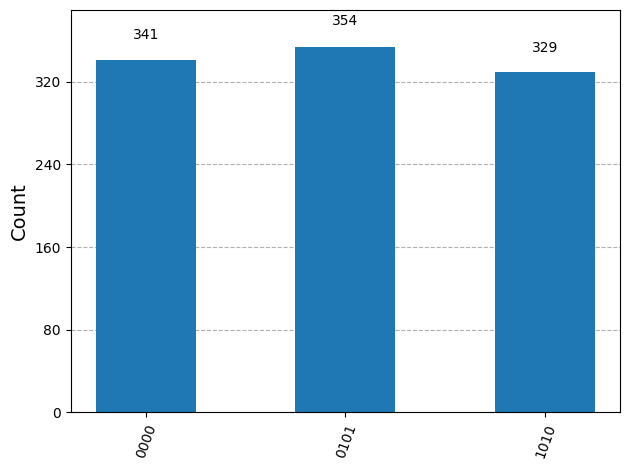

In [25]:
plot_histogram(result[0].data.meas.get_counts())

In [29]:
res0 = result[0].data.meas.get_counts()["0000"]
res1 = result[0].data.meas.get_counts()["0101"]
res2 = result[0].data.meas.get_counts()["1010"]

ntot = res0 + res1 + res2

prob0 = res0 / ntot
prob1 = res1 / ntot
prob2 = res2 / ntot

fid = 1/3 * (prob0 + prob1 + prob2 + 2 * (re0sum + re1sum + re2sum))

In [30]:
fid

np.float64(1.0000000000000027)

In [32]:
backend = QiskitRuntimeService().backend("ibm_kingston")
target = backend.target

qiskit_runtime_service._resolve_cloud_instances:WARNING:2025-11-20 20:45:42,816: Default instance not set. Searching all available instances.


In [33]:
pm = generate_preset_pass_manager(target=target, optimization_level=3)

In [34]:
qc2_isa = pm.run(qc2)

In [35]:
oppauli1_isa = [SparsePauliOp.from_operator(op).apply_layout(layout=qc2_isa.layout) for op in op01]
oppauli2_isa = [SparsePauliOp.from_operator(op).apply_layout(layout=qc2_isa.layout) for op in op02]
oppauli3_isa = [SparsePauliOp.from_operator(op).apply_layout(layout=qc2_isa.layout) for op in op12]

In [39]:
pub_isa = (qc2_isa, [oppauli1_isa, oppauli2_isa, oppauli3_isa])

In [40]:
est = AerEstimator()

job = aer.run([pub_isa])
result = job.result()

re0sum = 1/4 * (result[0].data.evs[0][0] - result[0].data.evs[0][1])
re1sum = 1/4 * (result[0].data.evs[1][0] - result[0].data.evs[1][1])
re2sum = 1/4 * (result[0].data.evs[2][0] - result[0].data.evs[2][1])

In [41]:
aersam = AerSampler()

In [43]:
jobsam = aersam.run([(qc2_isa)])

In [44]:
resultsam = jobsam.result()

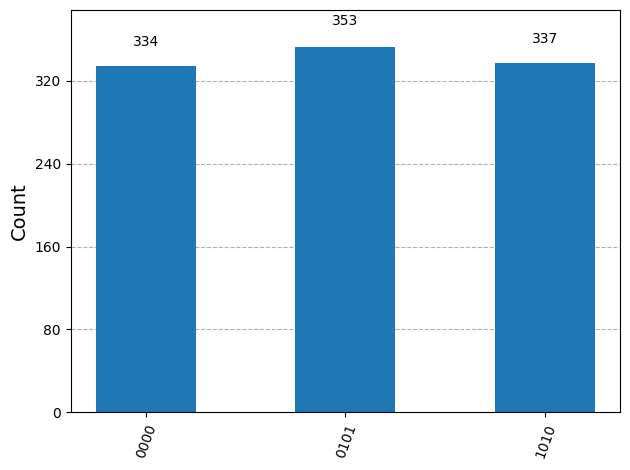

In [45]:
plot_histogram(resultsam[0].data.meas.get_counts())

In [75]:
with Batch(backend=backend) as batch:
    est_ibm = Estimator()
    est_ibm.options.default_shots = 1024
    #est_ibm.options.resilience_level = 2
    job_ibm = est_ibm.run([pub_isa])

In [76]:
with Batch(backend=backend) as batch:
    sam_ibm = Sampler()
    #sam_ibm.options.default_shots = 1024
    jobsam_ibm = sam_ibm.run([(qc2_isa)])

In [78]:
result = job_ibm.result()

re0sum = 1/4 * (result[0].data.evs[0][0] - result[0].data.evs[0][1])
re1sum = 1/4 * (result[0].data.evs[1][0] - result[0].data.evs[1][1])
re2sum = 1/4 * (result[0].data.evs[2][0] - result[0].data.evs[2][1])

resultsam = jobsam_ibm.result()

res0 = resultsam[0].data.meas.get_counts()["0000"]
res1 = resultsam[0].data.meas.get_counts()["0101"]
res2 = resultsam[0].data.meas.get_counts()["1010"]

ntot = res0 + res1 + res2

prob0 = res0 / ntot
prob1 = res1 / ntot
prob2 = res2 / ntot

fid = 1/3 * (prob0 + prob1 + prob2 + 2 * (re0sum + re1sum + re2sum))

In [79]:
fid

np.float64(0.921436565948494)

In [55]:
result = job_ibm.result()

re0sum = 1/4 * (result[0].data.evs[0][0] - result[0].data.evs[0][1])
re1sum = 1/4 * (result[0].data.evs[1][0] - result[0].data.evs[1][1])
re2sum = 1/4 * (result[0].data.evs[2][0] - result[0].data.evs[2][1])

resultsam = jobsam_ibm.result()

res0 = resultsam[0].data.meas.get_counts()["0000"]
res1 = resultsam[0].data.meas.get_counts()["0101"]
res2 = resultsam[0].data.meas.get_counts()["1010"]

ntot = res0 + res1 + res2

prob0 = res0 / ntot
prob1 = res1 / ntot
prob2 = res2 / ntot

fid = 1/3 * (prob0 + prob1 + prob2 + 2 * (re0sum + re1sum + re2sum))

In [56]:
fid

np.float64(0.9245594984077277)

In [59]:
result = job_ibm.result()

re0sum = 1/4 * (result[0].data.evs[0][0] - result[0].data.evs[0][1])
re1sum = 1/4 * (result[0].data.evs[1][0] - result[0].data.evs[1][1])
re2sum = 1/4 * (result[0].data.evs[2][0] - result[0].data.evs[2][1])

resultsam = jobsam_ibm.result()

res0 = resultsam[0].data.meas.get_counts()["0000"]
res1 = resultsam[0].data.meas.get_counts()["0101"]
res2 = resultsam[0].data.meas.get_counts()["1010"]

ntot = res0 + res1 + res2

prob0 = res0 / ntot
prob1 = res1 / ntot
prob2 = res2 / ntot

fid = 1/3 * (prob0 + prob1 + prob2 + 2 * (re0sum + re1sum + re2sum))

In [60]:
fid

np.float64(0.9747984728274643)

In [61]:
result[0].data.stds

array([[0.03340033, 0.05634761],
       [0.02660595, 0.02272772],
       [0.02462972, 0.02991392]])

In [80]:
s1 = 1/4 * np.sqrt((result[0].data.stds[0][0]**2 + result[0].data.stds[0][1]**2))
s2 = 1/4 * np.sqrt((result[0].data.stds[1][0]**2 + result[0].data.stds[1][1]**2))
s3 = 1/4 * np.sqrt((result[0].data.stds[2][0]**2 + result[0].data.stds[2][1]**2))

In [81]:
var1 = np.sqrt(prob0 * (1 - prob0) / ntot)
var2 = np.sqrt(prob1 * (1 - prob1) / ntot)
var3 = np.sqrt(prob2 * (1 - prob2) / ntot)

In [82]:
stds_tot = 1/3 * np.sqrt(var1**2 + var2**2 + var3**2 + 1/64 * 4 * (s1**2 + s2**2 + s3**2))

Stds z mitygacja

In [74]:
stds_tot

np.float64(0.008958044130964463)

Stds bez mitygacji

In [83]:
stds_tot

np.float64(0.004484150029605629)